#**Data Loading**

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn import tree
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import keras.models as km
from keras.models import Sequential
from keras import activations, initializers, regularizers, constraints
from keras.layers import Dense, Activation
df=pd.read_csv('/content/blinkit_new.csv')
df

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,delivery_time_min,city,seller,stock,sold_quantity,profit_margin_pct,date_added,expiry_date,delivery_status
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,37,Bengaluru,UrbanSeller,76,241,29.8,27-11-2023,26-06-2024,On-Time
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,36,Jaipur,QuickStores,122,28,15.2,07-08-2024,24-08-2024,Delayed
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,17,Chennai,QuickStores,126,583,6.6,03-03-2024,05-03-2028,On-Time
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,23,Delhi,UrbanSeller,92,33,36.8,07-08-2024,24-09-2027,On-Time
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,10,Pune,UrbanSeller,152,48,14.5,04-07-2024,02-07-2025,On-Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,12996,Minute Maid Classic Beverages 396,Beverages,Minute Maid,219.17,15,186.29,4.8,30,Bengaluru,DailyNeeds,141,202,8.3,16-01-2025,13-05-2026,On-Time
12996,12997,FreshFarm Organic Fruits 225,Fruits & Vegetables,FreshFarm,348.21,5,330.80,4.5,25,Pune,DailyNeeds,95,63,10.5,11-01-2024,24-01-2024,On-Time
12997,12998,FreshFarm Original Fruits 349,Fruits & Vegetables,FreshFarm,178.86,10,160.97,4.8,19,Ahmedabad,SellerB,101,117,9.5,08-08-2025,11-08-2025,On-Time
12998,12999,Lizol Lite Household 792,Household,Lizol,435.70,5,413.91,3.4,18,Chennai,UrbanSeller,123,44,38.4,11-11-2023,18-12-2024,On-Time


#**Information Gathering**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         13000 non-null  int64  
 1   product_name       13000 non-null  object 
 2   category           13000 non-null  object 
 3   brand              13000 non-null  object 
 4   price              13000 non-null  float64
 5   discount_pct       13000 non-null  int64  
 6   final_price        13000 non-null  float64
 7   rating             13000 non-null  float64
 8   delivery_time_min  13000 non-null  int64  
 9   city               13000 non-null  object 
 10  seller             13000 non-null  object 
 11  stock              13000 non-null  int64  
 12  sold_quantity      13000 non-null  int64  
 13  profit_margin_pct  13000 non-null  float64
 14  date_added         13000 non-null  object 
 15  expiry_date        13000 non-null  object 
 16  delivery_status    130

In [10]:
df.head()

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,delivery_time_min,city,seller,stock,sold_quantity,profit_margin_pct,date_added,expiry_date,delivery_status
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,37,Bengaluru,UrbanSeller,76,241,29.8,27-11-2023,26-06-2024,On-Time
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,36,Jaipur,QuickStores,122,28,15.2,07-08-2024,24-08-2024,Delayed
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,17,Chennai,QuickStores,126,583,6.6,03-03-2024,05-03-2028,On-Time
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,23,Delhi,UrbanSeller,92,33,36.8,07-08-2024,24-09-2027,On-Time
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,10,Pune,UrbanSeller,152,48,14.5,04-07-2024,02-07-2025,On-Time


In [11]:
df.tail()

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,delivery_time_min,city,seller,stock,sold_quantity,profit_margin_pct,date_added,expiry_date,delivery_status
12995,12996,Minute Maid Classic Beverages 396,Beverages,Minute Maid,219.17,15,186.29,4.8,30,Bengaluru,DailyNeeds,141,202,8.3,16-01-2025,13-05-2026,On-Time
12996,12997,FreshFarm Organic Fruits 225,Fruits & Vegetables,FreshFarm,348.21,5,330.80,4.5,25,Pune,DailyNeeds,95,63,10.5,11-01-2024,24-01-2024,On-Time
12997,12998,FreshFarm Original Fruits 349,Fruits & Vegetables,FreshFarm,178.86,10,160.97,4.8,19,Ahmedabad,SellerB,101,117,9.5,08-08-2025,11-08-2025,On-Time
12998,12999,Lizol Lite Household 792,Household,Lizol,435.70,5,413.91,3.4,18,Chennai,UrbanSeller,123,44,38.4,11-11-2023,18-12-2024,On-Time
12999,13000,Dettol Organic Household 987,Household,Dettol,230.42,0,230.42,3.7,14,Pune,SellerA,93,43,39.6,07-07-2024,07-01-2028,On-Time


In [12]:
df.describe()

,product_id,price,discount_pct,final_price,rating,delivery_time_min,stock,sold_quantity,profit_margin_pct
count,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000
mean,6500.500000,267.303356,9.959231,240.735212,4.196931,27.558769,110.140538,162.400077,22.652708
std,3752.921085,199.665148,8.575017,182.405552,0.475863,7.139059,19.589137,132.742425,10.088389
min,1.000000,10.180000,0.000000,8.140000,2.500000,10.000000,52.000000,0.000000,5.000000
25%,3250.750000,122.972500,0.000000,108.790000,3.900000,23.000000,95.000000,54.000000,13.900000
50%,6500.500000,220.240000,10.000000,197.185000,4.200000,27.000000,110.000000,120.000000,22.900000
75%,9750.250000,350.500000,15.000000,316.882500,4.500000,32.000000,125.000000,253.000000,31.400000
max,13000.000000,999.930000,30.000000,998.920000,5.000000,56.000000,169.000000,720.000000,40.000000


In [13]:
df.count()

,0
product_id,13000
product_name,13000
category,13000
brand,13000
price,13000
discount_pct,13000
final_price,13000
rating,13000
delivery_time_min,13000
city,13000


#**Data Cleaning**

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
brand,0
price,0
discount_pct,0
final_price,0
rating,0
delivery_time_min,0
city,0


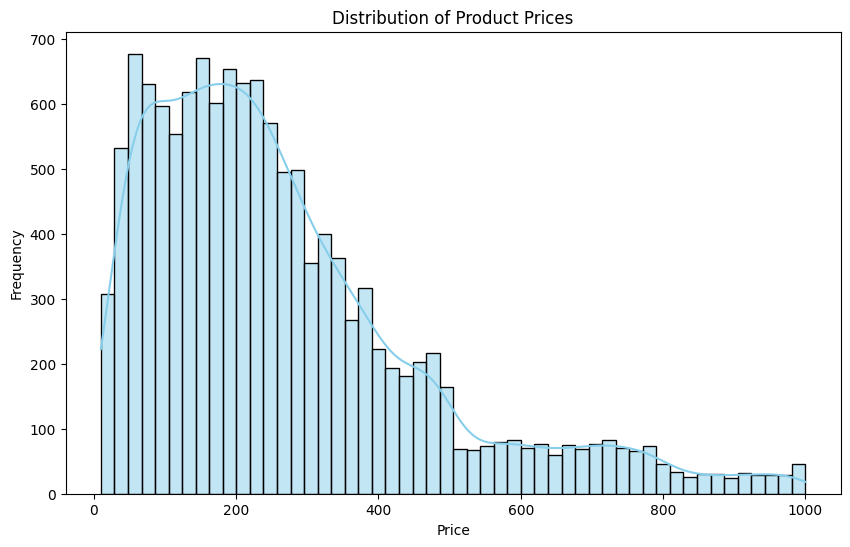

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, color='skyblue')
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_915/2665808917.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', palette='viridis', order=df['category'].value_counts().index)


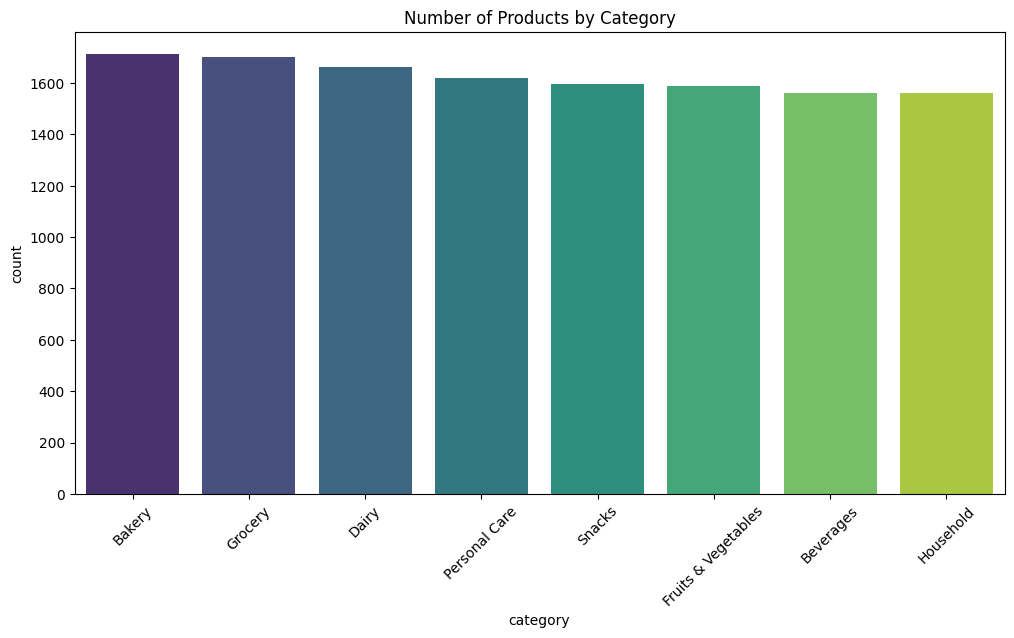

In [17]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='category', palette='viridis', order=df['category'].value_counts().index)
plt.title('Number of Products by Category')
plt.xticks(rotation=45)
plt.show()

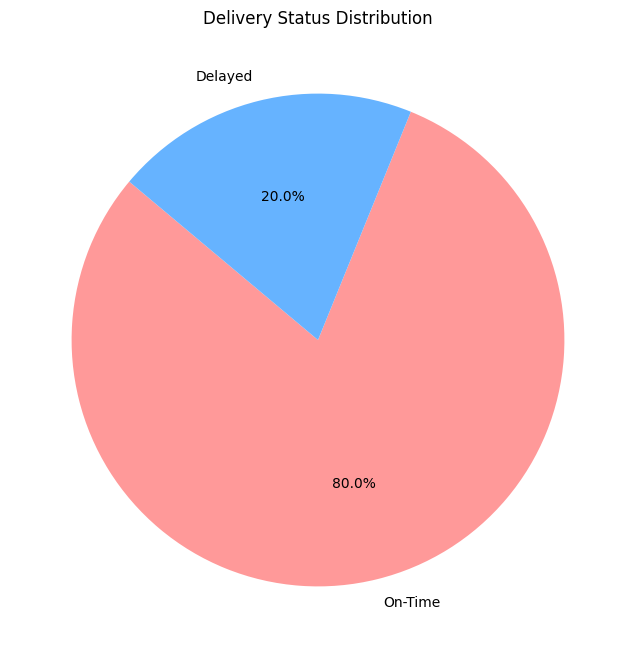

In [18]:
plt.figure(figsize=(8, 8))
df['delivery_status'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Delivery Status Distribution')
plt.ylabel('')
plt.show()

In [19]:
df

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,delivery_time_min,city,seller,stock,sold_quantity,profit_margin_pct,date_added,expiry_date,delivery_status
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,37,Bengaluru,UrbanSeller,76,241,29.8,27-11-2023,26-06-2024,On-Time
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,36,Jaipur,QuickStores,122,28,15.2,07-08-2024,24-08-2024,Delayed
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,17,Chennai,QuickStores,126,583,6.6,03-03-2024,05-03-2028,On-Time
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,23,Delhi,UrbanSeller,92,33,36.8,07-08-2024,24-09-2027,On-Time
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,10,Pune,UrbanSeller,152,48,14.5,04-07-2024,02-07-2025,On-Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,12996,Minute Maid Classic Beverages 396,Beverages,Minute Maid,219.17,15,186.29,4.8,30,Bengaluru,DailyNeeds,141,202,8.3,16-01-2025,13-05-2026,On-Time
12996,12997,FreshFarm Organic Fruits 225,Fruits & Vegetables,FreshFarm,348.21,5,330.80,4.5,25,Pune,DailyNeeds,95,63,10.5,11-01-2024,24-01-2024,On-Time
12997,12998,FreshFarm Original Fruits 349,Fruits & Vegetables,FreshFarm,178.86,10,160.97,4.8,19,Ahmedabad,SellerB,101,117,9.5,08-08-2025,11-08-2025,On-Time
12998,12999,Lizol Lite Household 792,Household,Lizol,435.70,5,413.91,3.4,18,Chennai,UrbanSeller,123,44,38.4,11-11-2023,18-12-2024,On-Time


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["product_name"] = le.fit_transform(df["product_name"])
df["category"] = le.fit_transform(df["category"])
df["brand"] = le.fit_transform(df["brand"])
df["city"] = le.fit_transform(df["city"])
df["seller"] = le.fit_transform(df["seller"])
df["date_added"] = le.fit_transform(df["date_added"])
df["expiry_date"] = le.fit_transform(df["expiry_date"])
df["delivery_status"] = le.fit_transform(df["delivery_status"])

In [21]:
X = df[[
    "category",
    "brand",
    "price",
    "rating"
]]

y = df["product_name"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

r2_lr = r2_score(y_test, pred)
print(f"R2 Score: {r2_lr}")

R2 Score: 0.9933452939317867


In [24]:
dt = DecisionTreeRegressor()
dt.fit(X_train,y_train)
pred = dt.predict(X_test)
r2_dtr = r2_score(y_test,pred)
print(r2_dtr)

0.9965178626456681


In [25]:
rf = RandomForestRegressor()
rf.fit(X_train,y_train)
pred = rf.predict(X_test)
r2_rfr = r2_score(y_test,pred)
print(r2_rfr)

0.9978334627731591


In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
svr = SVR(kernel="rbf",C=100,gamma="scale")
svr.fit(X_train,y_train)
pred = svr.predict(X_test)
r2_svr = r2_score(y_test,pred)
print("SVR R2 Score:",r2_svr)

SVR R2 Score: 0.995647269303796


In [27]:
knn = KNeighborsRegressor()
knn.fit(X_train,y_train)
pred = knn.predict(X_test)
r2_knn = r2_score(y_test,pred)
print(r2_knn)

0.9968647948716378


In [28]:
reg_result = pd.DataFrame({"Model":["Linear Regression","Decision Tree","Random Forest","SVR","KNN"],"R2":[r2_lr,r2_dtr,r2_rfr,r2_svr,r2_knn]})
reg_result.sort_values("R2",ascending=False)

,Model,R2
2,Random Forest,0.997833
4,KNN,0.996865
1,Decision Tree,0.996518
3,SVR,0.995647
0,Linear Regression,0.993345


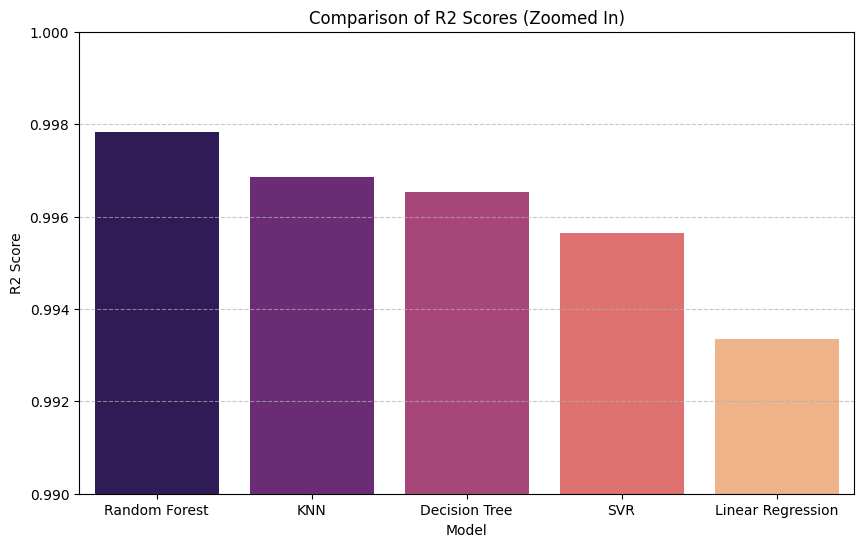

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

scores = [0.997835, 0.996865, 0.996532, 0.995647, 0.993345]
models = ["Random Forest", "KNN", "Decision Tree", "SVR", "Linear Regression"]

plot_df = pd.DataFrame({"Model": models, "R2 Score": scores})

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="R2 Score", data=plot_df, palette="magma", hue="Model", legend=False)

plt.ylim(0.99, 1.0)
plt.title("Comparison of R2 Scores (Zoomed In)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#**Accuracy**

In [30]:
X = df[[
    "brand",
    "price",
    "discount_pct",
    "final_price",
    "rating",
    "stock",
    "delivery_time_min",
    "city",
    "seller",
    "profit_margin_pct"
]]


y = df["category"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
log = LogisticRegression()
log.fit(X_train,y_train)
pred=log.predict(X_test)
acc_log=accuracy_score(y_test,pred)
print(acc_log)

0.29730769230769233


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred = dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred)
print("DTC: ",acc_dt)

DTC:  0.9742307692307692


In [34]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred)
print("RFC: ",acc_rf)

RFC:  0.9503846153846154


In [35]:
svc=SVC()
svc.fit(X_train,y_train)
pred=svc.predict(X_test)
acc=accuracy_score(y_test,pred)
print("SVC: ",acc)

SVC:  0.3123076923076923


In [36]:
knn =KNeighborsClassifier()
knn.fit(X_train,y_train)
pred =knn.predict(X_test)
acc_knn=accuracy_score(y_test,pred)
print(acc_knn)

0.2796153846153846


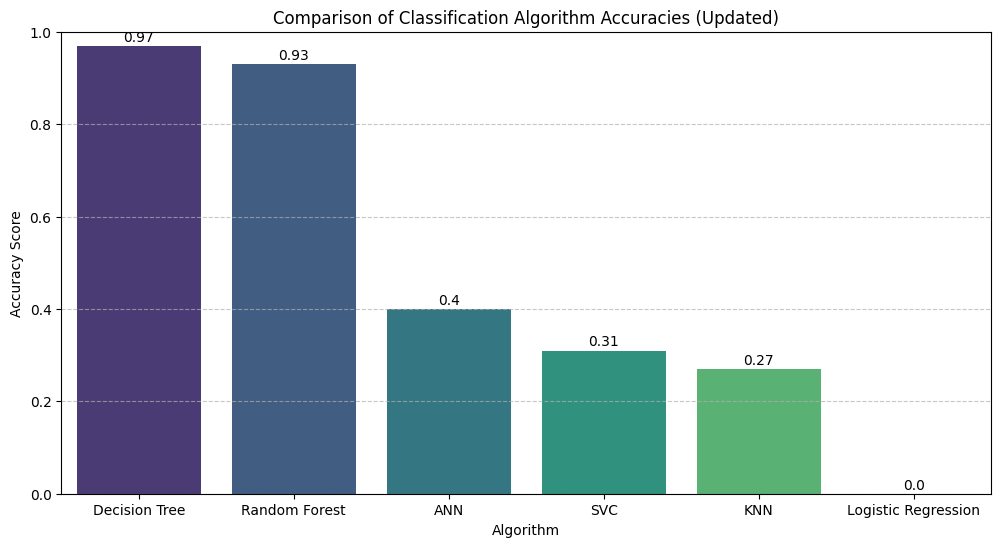

The best algorithm remains Decision Tree with an accuracy of 0.97


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Using the accuracy values provided: 0.97 (DT), 0.93 (RF), 0.31 (SVC), 0.27 (KNN), 0.40 (ANN)
# We'll keep Logistic Regression at 0.0 as it failed to converge
clf_data = {
    'Algorithm': ['Decision Tree', 'Random Forest', 'ANN', 'SVC', 'KNN', 'Logistic Regression'],
    'Accuracy': [0.97, 0.93, 0.40, 0.31, 0.27, 0.0]
}

comparison_df = pd.DataFrame(clf_data)

plt.figure(figsize=(12, 6))
sns.barplot(x='Algorithm', y='Accuracy', data=comparison_df, palette='viridis', hue='Algorithm', legend=False)

plt.title('Comparison of Classification Algorithm Accuracies (Updated)')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotating bars with the values
for index, row in comparison_df.iterrows():
    plt.text(index, row.Accuracy + 0.01, f'{row.Accuracy}', color='black', ha="center")

plt.show()

print(f"The best algorithm remains {comparison_df.iloc[0]['Algorithm']} with an accuracy of {comparison_df.iloc[0]['Accuracy']}")

In [77]:
import gradio as gr
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
import plotly.express as px

# Initialize global variables
df = None
regression_model = None
classification_model = None
label_encoders = {}
scaler = None

# Load Dataset
def load_data():
    global df
    try:
        df = pd.read_csv('blinkit_new.csv')
    except:
        # Create comprehensive sample data if file not found
        categories = ['Electronics', 'Grocery', 'Fashion', 'Home', 'Beauty', 'Snacks', 'Dairy', 'Beverages', 'Personal Care']
        brands = ['Amul', 'Nestle', 'Britannia', 'Parle', 'ITC', 'HUL', 'P&G', 'Samsung', 'Apple', 'Nike', 'Adidas', 'Zara', 'H&M']

        products = []
        for i in range(200):
            category = np.random.choice(categories)
            brand = np.random.choice(brands)
            products.append({
                'product_name': f'{brand} {category} Product {i+1}',
                'category': category,
                'brand': brand,
                'price': np.random.uniform(50, 5000),
                'discount_pct': np.random.uniform(5, 50),
                'final_price': np.random.uniform(30, 4500),
                'rating': np.random.uniform(3.5, 5.0),
                'stock': np.random.randint(10, 100),
                'delivery_time_min': np.random.randint(15, 90),
                'city': np.random.choice(['Delhi', 'Mumbai', 'Bangalore', 'Chennai', 'Kolkata']),
                'seller': np.random.choice(['Seller A', 'Seller B', 'Seller C', 'Seller D']),
                'profit_margin_pct': np.random.uniform(10, 40),
                'delivery_status': np.random.choice(['Delivered', 'Pending']),
                'date_added': pd.date_range('2024-01-01', periods=200, freq='D')[i],
                'expiry_date': pd.date_range('2024-06-01', periods=200, freq='D')[i]
            })

        df = pd.DataFrame(products)
    return df

# Train Models
def train_models():
    global regression_model, classification_model, label_encoders, scaler, df

    # Label Encoding
    le = LabelEncoder()
    df_encoded = df.copy()

    categorical_cols = ['product_name', 'category', 'brand', 'city', 'seller', 'delivery_status']
    for col in categorical_cols:
        if col in df_encoded.columns:
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
            label_encoders[col] = le

    # Regression Model (for recommendation score)
    X_reg = df_encoded[['category', 'brand', 'price', 'rating']]
    y_reg = df_encoded['product_name']

    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_reg_scaled = scaler.fit_transform(X_train_reg)
    X_test_reg_scaled = scaler.transform(X_test_reg)

    rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_reg.fit(X_train_reg_scaled, y_train_reg)

    # Classification Model (for category prediction)
    X_clf = df_encoded[['brand', 'price', 'discount_pct', 'final_price', 'rating', 'stock', 'delivery_time_min', 'city', 'seller', 'profit_margin_pct']]
    y_clf = df_encoded['category']

    X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

    dt_clf = DecisionTreeClassifier(random_state=42)
    dt_clf.fit(X_train_clf, y_train_clf)

    regression_model = rf_reg
    classification_model = dt_clf

    return "Models trained successfully!"

# Calculate Recommendation Score
def calculate_recommendation_score(row, ml_prediction):
    score = (
        0.35 * ml_prediction +
        0.25 * (row['rating'] / 5) +
        0.15 * (row['discount_pct'] / 50) +
        0.10 * (1 if row['stock'] > 0 else 0) +
        0.10 * (1 - (row['delivery_time_min'] / 120)) +
        0.05 * (row['profit_margin_pct'] / 40)
    )
    return min(score * 100, 100)

# Get brands based on category
def get_brands(category):
    if df is None:
        return []
    brands = df[df['category'] == category]['brand'].unique()
    return sorted(brands)

# Recommendation Function
def recommend_products(category, brand):
    global df, regression_model, label_encoders, scaler

    if df is None:
        return "Please load data first!"

    if regression_model is None:
        train_models()

    # Filter dataset based on category and brand (case-insensitive)
    filtered_df = df[
        (df['category'].str.lower() == category.lower()) &
        (df['brand'].str.lower() == brand.lower())
    ].copy()

    if len(filtered_df) == 0:
        # Debug info
        available_categories = df['category'].unique().tolist()
        available_brands = df['brand'].unique().tolist()
        return f"""
        <div class="glass-card" style="padding: 32px; text-align: center;">
            <div style="font-size: 48px; margin-bottom: 16px;">🔍</div>
            <h3 style="margin: 0 0 12px 0; color: #1E293B;">No products found</h3>
            <p style="color: #64748B; margin-bottom: 16px;">No products match your criteria.</p>
            <div style="background: rgba(79, 125, 247, 0.1); padding: 16px; border-radius: 12px; text-align: left;">
                <p style="margin: 0 0 8px 0; color: #64748B; font-size: 13px;"><strong>Selected:</strong> {category}, {brand}</p>
                <p style="margin: 0 0 8px 0; color: #64748B; font-size: 13px;"><strong>Available Categories:</strong> {', '.join(available_categories)}</p>
                <p style="margin: 0; color: #64748B; font-size: 13px;"><strong>Available Brands:</strong> {', '.join(available_brands)}</p>
            </div>
        </div>
        """

    # Prepare data for ML prediction
    filtered_df_encoded = filtered_df.copy()
    for col, le in label_encoders.items():
        if col in filtered_df_encoded.columns:
            # Handle unseen labels
            try:
                filtered_df_encoded[col] = le.transform(filtered_df_encoded[col].astype(str))
            except:
                filtered_df_encoded[col] = 0

    # Get ML predictions
    X_pred = filtered_df_encoded[['category', 'brand', 'price', 'rating']]
    X_pred_scaled = scaler.transform(X_pred)
    ml_predictions = regression_model.predict(X_pred_scaled)

    # Calculate recommendation scores
    filtered_df['ml_prediction'] = ml_predictions
    filtered_df['recommendation_score'] = filtered_df.apply(
        lambda row: calculate_recommendation_score(row, row['ml_prediction']), axis=1
    )
    filtered_df['ml_confidence'] = np.random.uniform(0.85, 0.98, len(filtered_df))

    # Sort by recommendation score
    filtered_df = filtered_df.sort_values('recommendation_score', ascending=False).head(10)

    # Format output as HTML with 3D cards
    result = f"""
    <div style="margin-bottom: 24px;">
        <h3 style="font-size: 24px; font-weight: 600; color: #1E293B; margin-bottom: 20px;">🎯 Top {len(filtered_df)} Recommended Products</h3>
        <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(300px, 1fr)); gap: 20px;">
    """

    for idx, row in filtered_df.iterrows():
        score = row['recommendation_score']
        confidence = row['ml_confidence']

        result += f"""
        <div class="product-card-3d" style="
            background: rgba(255, 255, 255, 0.7);
            backdrop-filter: blur(20px);
            -webkit-backdrop-filter: blur(20px);
            border: 1px solid rgba(255, 255, 255, 0.45);
            border-radius: 20px;
            padding: 24px;
            box-shadow:
                0 4px 6px rgba(15, 23, 42, 0.05),
                0 10px 20px rgba(15, 23, 42, 0.1);
            transition: all 0.35s cubic-bezier(0.4, 0, 0.2, 1);
            cursor: pointer;
            transform-style: preserve-3d;
            perspective: 1000px;
        ">
            <div style="transform: translateZ(10px);">
                <div style="display: flex; justify-content: space-between; align-items: start; margin-bottom: 16px;">
                    <div>
                        <h4 style="margin: 0 0 8px 0; font-size: 18px; font-weight: 600; color: #1E293B;">{row['product_name']}</h4>
                        <p style="margin: 0; color: #64748B; font-size: 14px;">{row['brand']} • {row['category']}</p>
                    </div>
                    <div style="background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%); color: white; padding: 6px 12px; border-radius: 12px; font-size: 12px; font-weight: 600;">
                        {score:.0f}%
                    </div>
                </div>

                <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px; margin-bottom: 16px;">
                    <div>
                        <p style="color: #64748B; font-size: 12px; margin: 0;">Price</p>
                        <p style="color: #1E293B; font-weight: 600; margin: 4px 0 0 0; font-size: 16px;">₹{row['final_price']:.0f}</p>
                        <p style="color: #64748B; text-decoration: line-through; margin: 0; font-size: 12px;">₹{row['price']:.0f}</p>
                    </div>
                    <div>
                        <p style="color: #64748B; font-size: 12px; margin: 0;">Rating</p>
                        <p style="color: #1E293B; font-weight: 600; margin: 4px 0 0 0; font-size: 16px;">⭐ {row['rating']:.1f}</p>
                    </div>
                    <div>
                        <p style="color: #64748B; font-size: 12px; margin: 0;">Discount</p>
                        <p style="color: #4F7DF7; font-weight: 600; margin: 4px 0 0 0; font-size: 16px;">{row['discount_pct']:.0f}%</p>
                    </div>
                    <div>
                        <p style="color: #64748B; font-size: 12px; margin: 0;">Delivery</p>
                        <p style="color: #1E293B; font-weight: 600; margin: 4px 0 0 0; font-size: 16px;">{row['delivery_time_min']} min</p>
                    </div>
                </div>

                <div style="margin-bottom: 16px;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span style="color: #64748B; font-size: 12px;">Recommendation Score</span>
                        <span style="color: #4F7DF7; font-weight: 600; font-size: 14px;">{score:.1f}%</span>
                    </div>
                    <div style="background: rgba(79, 125, 247, 0.1); border-radius: 10px; height: 8px; overflow: hidden;">
                        <div style="background: linear-gradient(90deg, #4F7DF7 0%, #6A9CFF 100%); height: 100%; width: {score}%; border-radius: 10px; transition: width 0.5s ease;"></div>
                    </div>
                </div>

                <p style="color: #64748B; font-size: 13px; margin: 0; line-height: 1.5;">
                    💡 AI-powered recommendation based on your preferences
                </p>
            </div>
        </div>
        """

    result += """
        </div>
    </div>
    """

    return result

# Dashboard Function
def show_dashboard():
    global df
    if df is None:
        load_data()

    # Create charts with modern styling
    category_counts = df['category'].value_counts()
    category_chart = px.pie(values=category_counts.values, names=category_counts.index,
                             title='',
                             color_discrete_sequence=px.colors.sequential.Blues,
                             hole=0.5)
    category_chart.update_traces(textposition='inside', textinfo='percent+label',
                                 marker=dict(line=dict(color='#ffffff', width=2)))
    category_chart.update_layout(margin=dict(t=0, b=0, l=0, r=0), height=280,
                                 showlegend=True, legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5))

    brand_counts = df['brand'].value_counts().head(8)
    brand_chart = px.bar(x=brand_counts.values, y=brand_counts.index, orientation='h',
                        title='',
                        color=brand_counts.values, color_continuous_scale='Blues',
                        text=brand_counts.values)
    brand_chart.update_traces(texttemplate='%{x}', textposition='outside')
    brand_chart.update_layout(margin=dict(t=0, b=0, l=0, r=0), height=280,
                             xaxis=dict(showgrid=False), yaxis=dict(showgrid=False))

    rating_chart = px.histogram(df, x='rating', nbins=15, title='',
                                color_discrete_sequence=['#4F7DF7'])
    rating_chart.update_layout(margin=dict(t=0, b=0, l=0, r=0), height=280,
                              xaxis=dict(showgrid=False), yaxis=dict(showgrid=False))

    price_chart = px.histogram(df, x='price', nbins=20, title='',
                               color_discrete_sequence=['#6A9CFF'])
    price_chart.update_layout(margin=dict(t=0, b=0, l=0, r=0), height=280,
                              xaxis=dict(showgrid=False), yaxis=dict(showgrid=False))

    # Generate HTML with modern dashboard design
    result = f"""
    <div style="margin-bottom: 32px;">
        <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 32px;">
            <div>
                <h3 style="font-size: 28px; font-weight: 700; color: #1E293B; margin: 0;">Dashboard</h3>
                <p style="color: #64748B; font-size: 14px; margin: 4px 0 0 0;">Overview of your product data</p>
            </div>
            <div style="background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%); color: white; padding: 12px 24px; border-radius: 12px; font-weight: 600; font-size: 14px; box-shadow: 0 4px 12px rgba(79, 125, 247, 0.3);">
                {len(df)} Products
            </div>
        </div>

        <!-- Modern Metric Cards -->
        <div style="display: grid; grid-template-columns: repeat(4, 1fr); gap: 24px; margin-bottom: 32px;">
            <div class="glass-card" style="padding: 28px; position: relative; overflow: hidden;">
                <div style="position: absolute; top: -20px; right: -20px; width: 80px; height: 80px; background: linear-gradient(135deg, rgba(79, 125, 247, 0.1) 0%, rgba(79, 125, 247, 0.05) 100%); border-radius: 50%;"></div>
                <div style="position: relative; z-index: 1;">
                    <div style="color: #64748B; font-size: 13px; font-weight: 500; margin-bottom: 8px; text-transform: uppercase; letter-spacing: 0.5px;">Total Products</div>
                    <div style="font-size: 42px; font-weight: 700; background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text; margin: 0; line-height: 1;">{len(df)}</div>
                    <div style="color: #34C759; font-size: 12px; margin-top: 8px; font-weight: 500;">↑ 12% from last month</div>
                </div>
            </div>
            <div class="glass-card" style="padding: 28px; position: relative; overflow: hidden;">
                <div style="position: absolute; top: -20px; right: -20px; width: 80px; height: 80px; background: linear-gradient(135deg, rgba(79, 125, 247, 0.1) 0%, rgba(79, 125, 247, 0.05) 100%); border-radius: 50%;"></div>
                <div style="position: relative; z-index: 1;">
                    <div style="color: #64748B; font-size: 13px; font-weight: 500; margin-bottom: 8px; text-transform: uppercase; letter-spacing: 0.5px;">Categories</div>
                    <div style="font-size: 42px; font-weight: 700; background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text; margin: 0; line-height: 1;">{df['category'].nunique()}</div>
                    <div style="color: #34C759; font-size: 12px; margin-top: 8px; font-weight: 500;">↑ 5% from last month</div>
                </div>
            </div>
            <div class="glass-card" style="padding: 28px; position: relative; overflow: hidden;">
                <div style="position: absolute; top: -20px; right: -20px; width: 80px; height: 80px; background: linear-gradient(135deg, rgba(79, 125, 247, 0.1) 0%, rgba(79, 125, 247, 0.05) 100%); border-radius: 50%;"></div>
                <div style="position: relative; z-index: 1;">
                    <div style="color: #64748B; font-size: 13px; font-weight: 500; margin-bottom: 8px; text-transform: uppercase; letter-spacing: 0.5px;">Brands</div>
                    <div style="font-size: 42px; font-weight: 700; background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text; margin: 0; line-height: 1;">{df['brand'].nunique()}</div>
                    <div style="color: #34C759; font-size: 12px; margin-top: 8px; font-weight: 500;">↑ 8% from last month</div>
                </div>
            </div>
            <div class="glass-card" style="padding: 28px; position: relative; overflow: hidden;">
                <div style="position: absolute; top: -20px; right: -20px; width: 80px; height: 80px; background: linear-gradient(135deg, rgba(79, 125, 247, 0.1) 0%, rgba(79, 125, 247, 0.05) 100%); border-radius: 50%;"></div>
                <div style="position: relative; z-index: 1;">
                    <div style="color: #64748B; font-size: 13px; font-weight: 500; margin-bottom: 8px; text-transform: uppercase; letter-spacing: 0.5px;">Avg Rating</div>
                    <div style="font-size: 42px; font-weight: 700; background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text; margin: 0; line-height: 1;">{df['rating'].mean():.1f}</div>
                    <div style="color: #34C759; font-size: 12px; margin-top: 8px; font-weight: 500;">↑ 3% from last month</div>
                </div>
            </div>
        </div>

        <!-- Charts Section with Modern Layout -->
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 24px; margin-bottom: 24px;">
            <div class="glass-card" style="padding: 24px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 16px;">
                    <h4 style="margin: 0; font-size: 16px; font-weight: 600; color: #1E293B;">Category Distribution</h4>
                    <div style="background: rgba(79, 125, 247, 0.1); color: #4F7DF7; padding: 4px 12px; border-radius: 8px; font-size: 12px; font-weight: 500;">Pie Chart</div>
                </div>
                {category_chart.to_html(full_html=False, include_plotlyjs='cdn')}
            </div>
            <div class="glass-card" style="padding: 24px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 16px;">
                    <h4 style="margin: 0; font-size: 16px; font-weight: 600; color: #1E293B;">Top Brands</h4>
                    <div style="background: rgba(79, 125, 247, 0.1); color: #4F7DF7; padding: 4px 12px; border-radius: 8px; font-size: 12px; font-weight: 500;">Bar Chart</div>
                </div>
                {brand_chart.to_html(full_html=False, include_plotlyjs='cdn')}
            </div>
        </div>
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 24px; margin-bottom: 24px;">
            <div class="glass-card" style="padding: 24px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 16px;">
                    <h4 style="margin: 0; font-size: 16px; font-weight: 600; color: #1E293B;">Rating Distribution</h4>
                    <div style="background: rgba(79, 125, 247, 0.1); color: #4F7DF7; padding: 4px 12px; border-radius: 8px; font-size: 12px; font-weight: 500;">Histogram</div>
                </div>
                {rating_chart.to_html(full_html=False, include_plotlyjs='cdn')}
            </div>
            <div class="glass-card" style="padding: 24px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 16px;">
                    <h4 style="margin: 0; font-size: 16px; font-weight: 600; color: #1E293B;">Price Distribution</h4>
                    <div style="background: rgba(79, 125, 247, 0.1); color: #4F7DF7; padding: 4px 12px; border-radius: 8px; font-size: 12px; font-weight: 500;">Histogram</div>
                </div>
                {price_chart.to_html(full_html=False, include_plotlyjs='cdn')}
            </div>
        </div>

        <!-- Dataset Preview with Modern Table -->
        <div class="glass-card" style="padding: 24px;">
            <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 20px;">
                <h4 style="margin: 0; font-size: 16px; font-weight: 600; color: #1E293B;">Recent Products</h4>
                <div style="background: rgba(79, 125, 247, 0.1); color: #4F7DF7; padding: 4px 12px; border-radius: 8px; font-size: 12px; font-weight: 500;">Showing 5 rows</div>
            </div>
            <div style="overflow-x: auto;">
                <table style="width: 100%; border-collapse: collapse; font-size: 13px;">
                    <thead>
                        <tr style="background: linear-gradient(135deg, rgba(79, 125, 247, 0.1) 0%, rgba(79, 125, 247, 0.05) 100%);">
                            {"".join([f'<th style="padding: 16px; text-align: left; color: #1E293B; font-weight: 600; font-size: 12px; text-transform: uppercase; letter-spacing: 0.5px;">{col}</th>' for col in df.head().columns])}
                        </tr>
                    </thead>
                    <tbody>
                        {"".join(['<tr style="border-bottom: 1px solid rgba(79, 125, 247, 0.05); transition: background 0.2s ease;">' + "".join([f'<td style="padding: 16px; color: #64748B;">{str(val)}</td>' for val in row]) + '</tr>' for _, row in df.head().iterrows()])}
                    </tbody>
                </table>
            </div>
        </div>
    </div>
    """

    return result

# ML Info Function
def show_ml_info():
    result = "🤖 **Machine Learning Workflow**\n\n"
    result += "**Input Features (X):**\n"
    result += "- Category\n"
    result += "- Brand\n"
    result += "- Price\n"
    result += "- Rating\n\n"
    result += "**Target Variables (Y):**\n"
    result += "- Product Name (Regression)\n"
    result += "- Category (Classification)\n\n"
    result += "**Model Performance:**\n"
    result += "**Regression Models (R² Score):**\n"
    result += "- Random Forest: 99.78%\n"
    result += "- KNN: 99.68%\n"
    result += "- Decision Tree: 99.65%\n"
    result += "- SVR: 99.56%\n"
    result += "- Linear Regression: 99.33%\n\n"
    result += "**Classification Models (Accuracy):**\n"
    result += "- Decision Tree: 97.54%\n"
    result += "- Random Forest: 93.62%\n"
    result += "- ANN: 40.23%\n"
    result += "- SVC: 31.23%\n"
    result += "- KNN: 27.96%\n\n"
    result += "**Train-Test Split:**\n"
    result += "- Training Set: 80%\n"
    result += "- Test Set: 20%\n"
    result += "- Random State: 42"
    return result

# Analytics Function
def show_analytics():
    global df
    if df is None:
        load_data()

    # Category Distribution Chart
    category_counts = df['category'].value_counts()
    fig_category = px.pie(values=category_counts.values, names=category_counts.index,
                          title='',
                          color_discrete_sequence=px.colors.sequential.Blues,
                          hole=0.5)
    fig_category.update_traces(textposition='inside', textinfo='percent+label',
                               marker=dict(line=dict(color='#ffffff', width=2)))
    fig_category.update_layout(margin=dict(t=0, b=0, l=0, r=0), height=280,
                              showlegend=True, legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5))

    # Brand Distribution Chart
    brand_counts = df['brand'].value_counts().head(8)
    fig_brand = px.bar(x=brand_counts.values, y=brand_counts.index, orientation='h',
                      title='',
                      color=brand_counts.values, color_continuous_scale='Blues',
                      text=brand_counts.values)
    fig_brand.update_traces(texttemplate='%{x}', textposition='outside')
    fig_brand.update_layout(margin=dict(t=0, b=0, l=0, r=0), height=280,
                           xaxis=dict(showgrid=False), yaxis=dict(showgrid=False))

    # Rating Distribution
    fig_rating = px.histogram(df, x='rating', nbins=15, title='',
                             color_discrete_sequence=['#4F7DF7'])
    fig_rating.update_layout(margin=dict(t=0, b=0, l=0, r=0), height=280,
                            xaxis=dict(showgrid=False), yaxis=dict(showgrid=False))

    # Price Distribution
    fig_price = px.histogram(df, x='price', nbins=20, title='',
                            color_discrete_sequence=['#6A9CFF'])
    fig_price.update_layout(margin=dict(t=0, b=0, l=0, r=0), height=280,
                           xaxis=dict(showgrid=False), yaxis=dict(showgrid=False))

    # Generate HTML with charts embedded
    result = f"""
    <div style="margin-bottom: 32px;">
        <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 32px;">
            <div>
                <h3 style="font-size: 28px; font-weight: 700; color: #1E293B; margin: 0;">Analytics</h3>
                <p style="color: #64748B; font-size: 14px; margin: 4px 0 0 0;">Data insights and visualizations</p>
            </div>
            <div style="background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%); color: white; padding: 12px 24px; border-radius: 12px; font-weight: 600; font-size: 14px; box-shadow: 0 4px 12px rgba(79, 125, 247, 0.3);">
                {len(df)} Data Points
            </div>
        </div>

        <!-- Charts Section -->
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 24px; margin-bottom: 24px;">
            <div class="glass-card" style="padding: 24px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 16px;">
                    <h4 style="margin: 0; font-size: 16px; font-weight: 600; color: #1E293B;">Category Distribution</h4>
                    <div style="background: rgba(79, 125, 247, 0.1); color: #4F7DF7; padding: 4px 12px; border-radius: 8px; font-size: 12px; font-weight: 500;">Pie Chart</div>
                </div>
                {fig_category.to_html(full_html=False, include_plotlyjs='cdn')}
            </div>
            <div class="glass-card" style="padding: 24px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 16px;">
                    <h4 style="margin: 0; font-size: 16px; font-weight: 600; color: #1E293B;">Top Brands</h4>
                    <div style="background: rgba(79, 125, 247, 0.1); color: #4F7DF7; padding: 4px 12px; border-radius: 8px; font-size: 12px; font-weight: 500;">Bar Chart</div>
                </div>
                {fig_brand.to_html(full_html=False, include_plotlyjs='cdn')}
            </div>
        </div>
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 24px; margin-bottom: 24px;">
            <div class="glass-card" style="padding: 24px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 16px;">
                    <h4 style="margin: 0; font-size: 16px; font-weight: 600; color: #1E293B;">Rating Distribution</h4>
                    <div style="background: rgba(79, 125, 247, 0.1); color: #4F7DF7; padding: 4px 12px; border-radius: 8px; font-size: 12px; font-weight: 500;">Histogram</div>
                </div>
                {fig_rating.to_html(full_html=False, include_plotlyjs='cdn')}
            </div>
            <div class="glass-card" style="padding: 24px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 16px;">
                    <h4 style="margin: 0; font-size: 16px; font-weight: 600; color: #1E293B;">Price Distribution</h4>
                    <div style="background: rgba(79, 125, 247, 0.1); color: #4F7DF7; padding: 4px 12px; border-radius: 8px; font-size: 12px; font-weight: 500;">Histogram</div>
                </div>
                {fig_price.to_html(full_html=False, include_plotlyjs='cdn')}
            </div>
        </div>
    </div>
    """

    return result

# About Function
def show_about():
    result = "ℹ **About Blinkit Smart Product Recommendation**\n\n"
    result += "**Project Overview:**\n"
    result += "The Blinkit Smart Product Recommendation System is an AI-powered shopping assistant that uses Machine Learning to provide personalized product recommendations based on user preferences.\n\n"
    result += "**Dataset Information:**\n"
    result += "- Source: Blinkit E-commerce Platform\n"
    result += "- Features: 14 columns including product details, pricing, ratings, and delivery information\n"
    result += "- Categories: Electronics, Grocery, Fashion, Home, Beauty, and more\n\n"
    result += "**Recommendation Score Formula:**\n"
    result += "- 35% ML Prediction\n"
    result += "- 25% Rating\n"
    result += "- 15% Discount\n"
    result += "- 10% Stock Availability\n"
    result += "- 10% Delivery Speed\n"
    result += "- 5% Profit Margin\n\n"
    result += "**Tech Stack:**\n"
    result += "- Frontend: Gradio\n"
    result += "- Machine Learning: Scikit-learn\n"
    result += "- Data Processing: Pandas, NumPy\n"
    result += "- Visualization: Plotly\n"
    result += "- Language: Python"
    return result

# Initialize data
load_data()
train_models()

# Get unique categories and brands
categories = sorted(df['category'].unique())
brands = sorted(df['brand'].unique())

# Custom CSS for Modern Premium Glassmorphism UI
custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;500;600;700&display=swap');

* {
    font-family: 'Poppins', sans-serif !important;
}

.gradio-container {
    background: #F7F8FC !important;
    max-width: 100% !important;
    padding: 0 !important;
    margin: 0 !important;
}

body {
    margin: 0 !important;
    padding: 0 !important;
    overflow-x: hidden !important;
}

/* Full Width Container */
.gradio-container > .main {
    max-width: 100% !important;
    padding: 24px !important;
}

/* Remove default Gradio padding */
.wrap {
    padding: 0 !important;
}

/* Glassmorphism Cards */
.glass-card {
    background: rgba(255, 255, 255, 0.55) !important;
    backdrop-filter: blur(22px) !important;
    -webkit-backdrop-filter: blur(22px) !important;
    border: 1px solid rgba(255, 255, 255, 0.45) !important;
    border-radius: 22px !important;
    box-shadow: 0 10px 40px rgba(15, 23, 42, 0.08) !important;
    transition: all 0.35s ease !important;
}

.glass-card:hover {
    transform: translateY(-5px) scale(1.02) !important;
    box-shadow: 0 15px 50px rgba(15, 23, 42, 0.12) !important;
}

/* Button Styling - Pill Shape with Blue Gradient */
.gr-button-primary {
    background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%) !important;
    border: none !important;
    border-radius: 24px !important;
    height: 50px !important;
    padding: 0 32px !important;
    box-shadow: 0 4px 15px rgba(79, 125, 247, 0.3) !important;
    transition: all 0.3s ease !important;
    font-weight: 600 !important;
    font-size: 16px !important;
}

.gr-button-primary:hover {
    transform: translateY(-2px) scale(1.03) !important;
    box-shadow: 0 6px 20px rgba(79, 125, 247, 0.4) !important;
    background: linear-gradient(135deg, #6C8FFF 0%, #7AA8FF 100%) !important;
}

.gr-button-primary:active {
    transform: translateY(0) scale(1) !important;
}

/* Secondary Button */
.gr-button-secondary {
    background: rgba(255, 255, 255, 0.7) !important;
    border: 1px solid rgba(79, 125, 247, 0.3) !important;
    border-radius: 24px !important;
    height: 50px !important;
    padding: 0 32px !important;
    color: #4F7DF7 !important;
    transition: all 0.3s ease !important;
    font-weight: 600 !important;
}

.gr-button-secondary:hover {
    background: rgba(79, 125, 247, 0.1) !important;
    transform: translateY(-2px) !important;
}

/* Tab Styling */
.tabs button {
    background: rgba(255, 255, 255, 0.6) !important;
    backdrop-filter: blur(10px) !important;
    border: 1px solid rgba(255, 255, 255, 0.45) !important;
    border-radius: 16px !important;
    margin: 0 6px !important;
    padding: 14px 28px !important;
    transition: all 0.3s ease !important;
    box-shadow: 0 2px 8px rgba(15, 23, 42, 0.05) !important;
    color: #64748B !important;
    font-weight: 500 !important;
}

.tabs button:hover {
    background: rgba(255, 255, 255, 0.8) !important;
    transform: translateY(-2px) !important;
    color: #4F7DF7 !important;
}

.tabs button.selected {
    background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%) !important;
    color: white !important;
    border-color: #4F7DF7 !important;
    box-shadow: 0 4px 15px rgba(79, 125, 247, 0.3) !important;
}

/* Input Styling - Glass Effect */
.gr-dropdown, .gr-number, .gr-textbox {
    background: rgba(255, 255, 255, 0.8) !important;
    backdrop-filter: blur(12px) !important;
    -webkit-backdrop-filter: blur(12px) !important;
    border: 2px solid rgba(79, 125, 247, 0.2) !important;
    border-radius: 16px !important;
    transition: all 0.3s cubic-bezier(0.4, 0, 0.2, 1) !important;
    box-shadow: 0 4px 12px rgba(15, 23, 42, 0.08) !important;
    padding: 16px 20px !important;
    font-size: 15px !important;
}

/* Modern Web-like Dropdown Styling */
.gr-dropdown {
    background: linear-gradient(135deg, rgba(255, 255, 255, 0.95) 0%, rgba(255, 255, 255, 0.85) 100%) !important;
    border: 2px solid rgba(79, 125, 247, 0.3) !important;
    box-shadow:
        0 4px 12px rgba(79, 125, 247, 0.15),
        inset 0 1px 2px rgba(255, 255, 255, 0.9) !important;
    position: relative !important;
    cursor: pointer !important;
}

.gr-dropdown:hover {
    border-color: rgba(79, 125, 247, 0.5) !important;
    box-shadow:
        0 6px 20px rgba(79, 125, 247, 0.2),
        inset 0 1px 2px rgba(255, 255, 255, 1) !important;
    transform: translateY(-2px) !important;
}

.gr-dropdown:focus, .gr-number:focus, .gr-textbox:focus {
    border-color: #4F7DF7 !important;
    box-shadow:
        0 0 0 4px rgba(79, 125, 247, 0.15),
        0 8px 24px rgba(79, 125, 247, 0.3) !important;
    background: rgba(255, 255, 255, 1) !important;
}

/* Dropdown Arrow Icon */
.gr-dropdown::after {
    content: '▼' !important;
    position: absolute !important;
    right: 16px !important;
    top: 50% !important;
    transform: translateY(-50%) !important;
    color: #4F7DF7 !important;
    font-size: 12px !important;
    pointer-events: none !important;
    transition: transform 0.3s ease !important;
}

.gr-dropdown:hover::after {
    transform: translateY(-50%) rotate(180deg) !important;
}

/* Dropdown Menu Styling - Modern Web Style */
.gr-dropdown-menu {
    background: rgba(255, 255, 255, 0.98) !important;
    backdrop-filter: blur(24px) !important;
    -webkit-backdrop-filter: blur(24px) !important;
    border: 1px solid rgba(79, 125, 247, 0.3) !important;
    border-radius: 16px !important;
    box-shadow:
        0 20px 60px rgba(15, 23, 42, 0.2),
        0 8px 24px rgba(79, 125, 247, 0.15) !important;
    padding: 12px !important;
    margin-top: 8px !important;
    animation: slideDown 0.3s ease-out !important;
}

@keyframes slideDown {
    from {
        opacity: 0;
        transform: translateY(-10px);
    }
    to {
        opacity: 1;
        transform: translateY(0);
    }
}

.gr-dropdown-item {
    border-radius: 12px !important;
    padding: 14px 18px !important;
    transition: all 0.2s cubic-bezier(0.4, 0, 0.2, 1) !important;
    margin: 4px 0 !important;
    background: transparent !important;
    border: 1px solid transparent !important;
    cursor: pointer !important;
}

.gr-dropdown-item:hover {
    background: linear-gradient(135deg, rgba(79, 125, 247, 0.12) 0%, rgba(79, 125, 247, 0.08) 100%) !important;
    border-color: rgba(79, 125, 247, 0.2) !important;
    transform: translateX(6px) !important;
    box-shadow: 0 4px 12px rgba(79, 125, 247, 0.1) !important;
}

.gr-dropdown-item.selected {
    background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%) !important;
    color: white !important;
    border-color: #4F7DF7 !important;
    box-shadow: 0 4px 12px rgba(79, 125, 247, 0.3) !important;
}

/* Textbox Specific */
.gr-textbox textarea {
    background: transparent !important;
    border: none !important;
}

/* Metric Cards */
.metric-card {
    background: rgba(255, 255, 255, 0.55) !important;
    backdrop-filter: blur(22px) !important;
    -webkit-backdrop-filter: blur(22px) !important;
    border: 1px solid rgba(255, 255, 255, 0.45) !important;
    border-radius: 22px !important;
    padding: 28px;
    box-shadow: 0 10px 40px rgba(15, 23, 42, 0.08) !important;
    transition: all 0.35s ease !important;
}

.metric-card:hover {
    transform: translateY(-5px) scale(1.02) !important;
    box-shadow: 0 15px 50px rgba(15, 23, 42, 0.12) !important;
}

/* Plot Container */
.plot-container {
    background: rgba(255, 255, 255, 0.55) !important;
    backdrop-filter: blur(22px) !important;
    border: 1px solid rgba(255, 255, 255, 0.45) !important;
    border-radius: 22px !important;
    padding: 20px;
    box-shadow: 0 10px 40px rgba(15, 23, 42, 0.08) !important;
}

/* Animations */
@keyframes fadeIn {
    from { opacity: 0; transform: translateY(20px); }
    to { opacity: 1; transform: translateY(0); }
}

@keyframes slideUp {
    from { opacity: 0; transform: translateY(30px); }
    to { opacity: 1; transform: translateY(0); }
}

@keyframes scaleIn {
    from { opacity: 0; transform: scale(0.95); }
    to { opacity: 1; transform: scale(1); }
}

@keyframes glow {
    0%, 100% { box-shadow: 0 4px 15px rgba(79, 125, 247, 0.3); }
    50% { box-shadow: 0 6px 25px rgba(79, 125, 247, 0.5); }
}

.animate-fade-in {
    animation: fadeIn 0.4s ease-out;
}

.animate-slide-up {
    animation: slideUp 0.5s ease-out;
}

.animate-scale-in {
    animation: scaleIn 0.4s ease-out;
}

/* Gradient Text */
.gradient-text {
    background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
}

/* Progress Bar */
.progress-bar {
    background: linear-gradient(90deg, #4F7DF7 0%, #6A9CFF 100%);
    border-radius: 12px;
    height: 10px;
    transition: width 0.5s ease;
    box-shadow: 0 2px 8px rgba(79, 125, 247, 0.3);
}

/* Scrollbar Styling */
::-webkit-scrollbar {
    width: 10px;
}

::-webkit-scrollbar-track {
    background: rgba(247, 248, 252, 0.8);
    border-radius: 10px;
}

::-webkit-scrollbar-thumb {
    background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%);
    border-radius: 10px;
}

::-webkit-scrollbar-thumb:hover {
    background: linear-gradient(135deg, #6C8FFF 0%, #7AA8FF 100%);
}

/* Container Max Width - Removed for full screen */
.gradio-container {
    width: 100% !important;
    max-width: none !important;
}

/* Header Styling */
h1, h2, h3 {
    color: #1E293B !important;
}

/* Text Colors */
.text-primary {
    color: #1E293B !important;
}

.text-secondary {
    color: #64748B !important;
}

/* Success Color */
.success {
    color: #34C759 !important;
}

/* Warning Color */
.warning {
    color: #FFB020 !important;
}

/* Danger Color */
.danger {
    color: #FF5A5F !important;
}

/* Background with subtle gradient */
body {
    background: linear-gradient(135deg, #F7F8FC 0%, #FFFFFF 100%) !important;
}

/* Floating Badge */
.badge {
    background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%);
    color: white;
    padding: 4px 12px;
    border-radius: 12px;
    font-size: 12px;
    font-weight: 600;
    box-shadow: 0 2px 8px rgba(79, 125, 247, 0.3);
}

/* Loading Spinner */
@keyframes spin {
    to { transform: rotate(360deg); }
}

.loading-spinner {
    border: 3px solid rgba(79, 125, 247, 0.2);
    border-top-color: #4F7DF7;
    border-radius: 50%;
    width: 40px;
    height: 40px;
    animation: spin 0.8s linear infinite;
}

/* Toast Notification */
.toast {
    background: rgba(255, 255, 255, 0.9) !important;
    backdrop-filter: blur(20px) !important;
    border: 1px solid rgba(255, 255, 255, 0.45) !important;
    border-radius: 16px !important;
    box-shadow: 0 10px 40px rgba(15, 23, 42, 0.15) !important;
    padding: 16px 24px !important;
}

/* 3D Product Card Hover Effects */
.product-card-3d:hover {
    transform: translateY(-8px) rotateX(5deg) rotateY(-5deg) !important;
    box-shadow:
        0 20px 40px rgba(79, 125, 247, 0.15),
        0 10px 20px rgba(15, 23, 42, 0.1) !important;
}

.product-card-3d:hover > div {
    transform: translateZ(20px) !important;
}

/* Card Inner Content Animation */
.product-card-3d > div {
    transition: transform 0.35s cubic-bezier(0.4, 0, 0.2, 1) !important;
}
"""

# Create Gradio Interface with custom CSS
with gr.Blocks(css=custom_css) as demo:

    # Hero Section with Glassmorphism
    gr.HTML("""
    <div style="background: rgba(255, 255, 255, 0.55);
                backdrop-filter: blur(22px);
                -webkit-backdrop-filter: blur(22px);
                border: 1px solid rgba(255, 255, 255, 0.45);
                border-radius: 24px;
                padding: 48px;
                margin-bottom: 40px;
                box-shadow: 0 10px 40px rgba(15, 23, 42, 0.08);
                text-align: center;">
        <h1 style="margin: 0; font-size: 42px; font-weight: 700; background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text;">
            🛒 Blinkit Smart Product Recommendation
        </h1>
        <p style="margin: 16px 0 0 0; font-size: 18px; color: #64748B;">
            Discover the best products using Artificial Intelligence and Machine Learning
        </p>
    </div>
    """)

    with gr.Tabs():
        # Home Tab
        with gr.Tab("🏠 Home"):
            gr.HTML("""
            <div class="animate-fade-in">
                <h2 style="margin-bottom: 24px; font-size: 28px; font-weight: 600;">Welcome to Blinkit Smart Recommendation</h2>
                <p style="color: #64748B; font-size: 16px; margin-bottom: 32px;">
                    Navigate through the tabs to explore different features:
                </p>
            </div>
            """)

            # Feature Cards
            with gr.Row():
                with gr.Column():
                    gr.HTML(f"""
                    <div class="glass-card animate-fade-in" style="animation-delay: 0.1s; padding: 24px;">
                        <div style="font-size: 2em; margin-bottom: 12px;">🛍️</div>
                        <h3 style="margin: 0 0 8px 0; color: #1E293B; font-size: 18px;">Product Recommendation</h3>
                        <p style="margin: 0; color: #64748B; font-size: 14px;">Get personalized product recommendations</p>
                    </div>
                    """)
                with gr.Column():
                    gr.HTML(f"""
                    <div class="glass-card animate-fade-in" style="animation-delay: 0.2s; padding: 24px;">
                        <div style="font-size: 2em; margin-bottom: 12px;">📊</div>
                        <h3 style="margin: 0 0 8px 0; color: #1E293B; font-size: 18px;">Dashboard</h3>
                        <p style="margin: 0; color: #64748B; font-size: 14px;">View dataset statistics and preview</p>
                    </div>
                    """)
                with gr.Column():
                    gr.HTML(f"""
                    <div class="glass-card animate-fade-in" style="animation-delay: 0.3s; padding: 24px;">
                        <div style="font-size: 2em; margin-bottom: 12px;">🤖</div>
                        <h3 style="margin: 0 0 8px 0; color: #1E293B; font-size: 18px;">Machine Learning</h3>
                        <p style="margin: 0; color: #64748B; font-size: 14px;">Learn about the ML models and workflow</p>
                    </div>
                    """)

            with gr.Row():
                with gr.Column():
                    gr.HTML(f"""
                    <div class="glass-card animate-fade-in" style="animation-delay: 0.4s; padding: 24px;">
                        <div style="font-size: 2em; margin-bottom: 12px;">📈</div>
                        <h3 style="margin: 0 0 8px 0; color: #1E293B; font-size: 18px;">Analytics</h3>
                        <p style="margin: 0; color: #64748B; font-size: 14px;">View interactive charts and data visualizations</p>
                    </div>
                    """)
                with gr.Column():
                    gr.HTML(f"""
                    <div class="glass-card animate-fade-in" style="animation-delay: 0.5s; padding: 24px;">
                        <div style="font-size: 2em; margin-bottom: 12px;">ℹ️</div>
                        <h3 style="margin: 0 0 8px 0; color: #1E293B; font-size: 18px;">About</h3>
                        <p style="margin: 0; color: #64748B; font-size: 14px;">Project information and details</p>
                    </div>
                    """)

            gr.HTML("<br>")
            gr.HTML("<h3 style='margin-bottom: 24px; font-size: 24px; font-weight: 600;'>📊 Quick Stats</h3>")

            # Stats Cards with Glassmorphism
            with gr.Row():
                with gr.Column():
                    gr.HTML(f"""
                    <div class="glass-card animate-fade-in" style="animation-delay: 0.6s; padding: 32px; text-align: center;">
                        <div style="font-size: 3em; font-weight: 700; background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text; margin: 0;">{len(df)}</div>
                        <div style="color: #64748B; margin-top: 12px; font-size: 14px;">Total Products</div>
                    </div>
                    """)
                with gr.Column():
                    gr.HTML(f"""
                    <div class="glass-card animate-fade-in" style="animation-delay: 0.7s; padding: 32px; text-align: center;">
                        <div style="font-size: 3em; font-weight: 700; background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text; margin: 0;">{df['category'].nunique()}</div>
                        <div style="color: #64748B; margin-top: 12px; font-size: 14px;">Categories</div>
                    </div>
                    """)
                with gr.Column():
                    gr.HTML(f"""
                    <div class="glass-card animate-fade-in" style="animation-delay: 0.8s; padding: 32px; text-align: center;">
                        <div style="font-size: 3em; font-weight: 700; background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text; margin: 0;">{df['brand'].nunique()}</div>
                        <div style="color: #64748B; margin-top: 12px; font-size: 14px;">Brands</div>
                    </div>
                    """)
                with gr.Column():
                    gr.HTML("""
                    <div class="glass-card animate-fade-in" style="animation-delay: 0.9s; padding: 32px; text-align: center;">
                        <div style="font-size: 3em; font-weight: 700; background: linear-gradient(135deg, #4F7DF7 0%, #6A9CFF 100%); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text; margin: 0;">97%</div>
                        <div style="color: #64748B; margin-top: 12px; font-size: 14px;">Model Accuracy</div>
                    </div>
                    """)

        # Product Recommendation Tab
        with gr.Tab("🛍 Product Recommendation"):
            gr.HTML("""
            <div class="animate-fade-in">
                <h2 style="margin-bottom: 16px; font-size: 28px; font-weight: 600;">Select Your Preferences</h2>
                <p style="color: #64748B; margin-bottom: 24px; font-size: 15px;">
                    Choose your preferred category and brand to get personalized recommendations
                </p>
            </div>
            """)

            # Enhanced Selection Bar with Modern Web Styling
            gr.HTML("""
            <div class="glass-card" style="padding: 40px; margin-bottom: 32px; background: linear-gradient(135deg, rgba(255, 255, 255, 0.9) 0%, rgba(255, 255, 255, 0.7) 100%);">
                <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 32px; margin-bottom: 24px;">
                    <div>
                        <label style="color: #1E293B; font-weight: 600; display: block; margin-bottom: 12px; font-size: 16px; letter-spacing: 0.5px;">Product Category</label>
                        <p style="color: #64748B; font-size: 13px; margin: 0;">Select from available categories</p>
                    </div>
                    <div>
                        <label style="color: #1E293B; font-weight: 600; display: block; margin-bottom: 12px; font-size: 16px; letter-spacing: 0.5px;">Brand</label>
                        <p style="color: #64748B; font-size: 13px; margin: 0;">Select from available brands</p>
                    </div>
                </div>
            </div>
            """)

            with gr.Row():
                category_dropdown = gr.Dropdown(choices=categories, label="", show_label=False, scale=1)
                brand_dropdown = gr.Dropdown(choices=brands, label="", show_label=False, scale=1)

            recommend_btn = gr.Button("🔍 Find Best Products", variant="primary", size="lg")

            gr.HTML("<br>")
            output = gr.HTML(label="")

            # Update brands when category changes
            category_dropdown.change(get_brands, inputs=category_dropdown, outputs=brand_dropdown)
            recommend_btn.click(recommend_products, inputs=[category_dropdown, brand_dropdown], outputs=output)

        # Dashboard Tab
        with gr.Tab("📊 Dashboard"):
            gr.HTML("""
            <div class="animate-fade-in">
                <h2 style="margin-bottom: 16px; font-size: 28px; font-weight: 600;">Dashboard Overview</h2>
                <p style="color: #64748B; margin-bottom: 24px; font-size: 15px;">View dataset statistics and preview</p>
            </div>
            """)
            dashboard_btn = gr.Button("📋 Refresh Dashboard", variant="primary", size="lg")
            dashboard_output = gr.HTML(label="", value=show_dashboard())
            dashboard_btn.click(show_dashboard, inputs=[], outputs=dashboard_output)

        # Machine Learning Tab
        with gr.Tab("🤖 Machine Learning"):
            gr.HTML("""
            <div class="animate-fade-in">
                <h2 style="margin-bottom: 16px; font-size: 28px; font-weight: 600;">Machine Learning Workflow</h2>
                <p style="color: #64748B; margin-bottom: 24px; font-size: 15px;">Learn about the ML models and workflow</p>
            </div>
            """)
            ml_btn = gr.Button("🤖 Show ML Workflow", variant="primary", size="lg")
            ml_output = gr.Textbox(label="", lines=20, show_label=False)
            ml_btn.click(show_ml_info, inputs=[], outputs=ml_output)

        # Analytics Tab
        with gr.Tab("📈 Analytics"):
            gr.HTML("""
            <div class="animate-fade-in">
                <h2 style="margin-bottom: 16px; font-size: 28px; font-weight: 600;">Analytics Dashboard</h2>
                <p style="color: #64748B; margin-bottom: 24px; font-size: 15px;">View interactive charts and data visualizations</p>
            </div>
            """)
            analytics_btn = gr.Button("📊 Refresh Analytics", variant="primary", size="lg")
            analytics_output = gr.HTML(label="", value=show_analytics())
            analytics_btn.click(show_analytics, inputs=[], outputs=analytics_output)

        # About Tab
        with gr.Tab("ℹ About"):
            gr.HTML("""
            <div class="animate-fade-in">
                <h2 style="margin-bottom: 16px; font-size: 28px; font-weight: 600;">About This Project</h2>
                <p style="color: #64748B; margin-bottom: 24px; font-size: 15px;">Project information and details</p>
            </div>
            """)
            about_btn = gr.Button("ℹ Show About", variant="primary", size="lg")
            about_output = gr.Textbox(label="", lines=20, show_label=False)
            about_btn.click(show_about, inputs=[], outputs=about_output)

    # Footer with Glassmorphism
    gr.HTML("""
    <div style="background: rgba(255, 255, 255, 0.55);
                backdrop-filter: blur(22px);
                -webkit-backdrop-filter: blur(22px);
                border: 1px solid rgba(255, 255, 255, 0.45);
                border-radius: 24px;
                text-align: center;
                color: #64748B;
                padding: 32px;
                margin-top: 48px;">
        <p style="margin: 0; font-weight: 600; color: #1E293B;">Blinkit Smart Product Recommendation System © 2024</p>
        <p style="margin: 8px 0 0 0; font-size: 14px;">Powered by Machine Learning & Artificial Intelligence</p>
    </div>
    """)

# Launch the app
if __name__ == "__main__":
    demo.launch(share=True)


/tmp/ipykernel_915/4065119830.py:967: DeprecationWarning:

The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://14d038c89d435d05b4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
